# 01 - Coleta, EDA e Pre-processamento

Notebook 1: carrega os arquivos `raw`, constroi o dataset final, executa EDA completa e salva os artefatos para o notebook 2.


## 1) Setup

In [1]:
import re
import unicodedata
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
ROOT = Path("..").resolve()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"
FIGURES_DIR = ROOT / "reports" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")

print("ROOT:", ROOT)
print("RAW:", RAW_DIR)
print("PROCESSED:", PROCESSED_DIR)


ROOT: /home/gabriel/projetos/socio_violence_predictor
RAW: /home/gabriel/projetos/socio_violence_predictor/data/raw
PROCESSED: /home/gabriel/projetos/socio_violence_predictor/data/processed


## 2) Carregando os arquivos Raw


In [2]:
censo = pd.read_csv(RAW_DIR / "censo2022_municipios.csv", dtype={"cod_ibge": str})
censo["cod_ibge"] = censo["cod_ibge"].str.zfill(7)

atlas_raw = pd.read_excel(RAW_DIR / "atlas_brasil_municipios.xlsx")
ibge_ref = pd.read_csv(RAW_DIR / "ibge_municipios_ref.csv", dtype={"cod_ibge": str})
pib_raw = pd.read_csv(RAW_DIR / "pib_municipios_sidra_2021.csv", dtype={"cod_ibge": str})

try:
    areas_raw = pd.read_excel(RAW_DIR / "areas_municipios_2024.xls", dtype={"CD_MUN": str})
except ImportError as exc:
    raise ImportError("Instale xlrd para ler areas_municipios_2024.xls: pip install xlrd") from exc

xl_sinesp = pd.ExcelFile(RAW_DIR / "sinesp_municipios.xlsx")
sinesp_raw = pd.concat([xl_sinesp.parse(sheet) for sheet in xl_sinesp.sheet_names], ignore_index=True)

print("censo:", censo.shape)
print("atlas:", atlas_raw.shape)
print("ibge_ref:", ibge_ref.shape)
print("pib_raw:", pib_raw.shape)
print("areas_raw:", areas_raw.shape)
print("sinesp_raw:", sinesp_raw.shape)

censo: (5570, 8)
atlas: (5569, 7)
ibge_ref: (5571, 4)
pib_raw: (5570, 2)
areas_raw: (5575, 6)
sinesp_raw: (294706, 6)


## 3) Tratamento Atlas + chave IBGE

In [3]:
def normalizar_nome(nome: str) -> str:
    if not isinstance(nome, str):
        return ""
    nfkd = unicodedata.normalize("NFKD", nome)
    sem_acento = "".join(c for c in nfkd if not unicodedata.combining(c))
    return re.sub(r"\s+", " ", sem_acento).strip().lower()

atlas_raw.columns = [
    "territorialidade",
    "gini",
    "idhm",
    "idhm_renda",
    "idhm_longevidade",
    "idhm_educacao",
    "perc_pobres",
]
atlas_raw = atlas_raw[atlas_raw["territorialidade"] != "Brasil"].copy()
atlas_parts = atlas_raw["territorialidade"].str.extract(r"^(.*)\s+\((\w{2})\)$")
atlas_raw["nome_mun"] = atlas_parts[0]
atlas_raw["uf"] = atlas_parts[1]
atlas_raw = atlas_raw[atlas_raw["nome_mun"].notna() & atlas_raw["uf"].notna()].copy()
atlas_raw["nome_norm"] = atlas_raw["nome_mun"].map(normalizar_nome)

if "nome_norm" not in ibge_ref.columns:
    ibge_ref["nome_norm"] = ibge_ref["nome_ibge"].map(normalizar_nome)

atlas = atlas_raw.merge(
    ibge_ref[["cod_ibge", "nome_norm", "uf"]],
    on=["nome_norm", "uf"],
    how="left",
)
atlas = atlas[["cod_ibge", "gini", "idhm", "idhm_renda", "idhm_longevidade", "idhm_educacao", "perc_pobres"]]

for col in ["gini", "idhm", "idhm_renda", "idhm_longevidade", "idhm_educacao", "perc_pobres"]:
    atlas[col] = pd.to_numeric(atlas[col], errors="coerce")

atlas_sem_codigo = int(atlas["cod_ibge"].isna().sum())
print("atlas sem cod_ibge:", atlas_sem_codigo)
if atlas_sem_codigo > 600:
    raise ValueError("Join Atlas x IBGE com baixa cobertura. Verifique normalizacao de nomes e UF.")
atlas.head()

atlas sem cod_ibge: 26


,cod_ibge,gini,idhm,idhm_renda,idhm_longevidade,idhm_educacao,perc_pobres
0,5200050,0.42,0.708,0.687,0.830,0.622,6.18
1,3100104,0.47,0.689,0.693,0.839,0.563,7.94
2,5200100,0.43,0.689,0.671,0.841,0.579,8.45
3,3100203,0.54,0.698,0.720,0.848,0.556,6.69
4,1500107,0.53,0.628,0.579,0.798,0.537,38.95


## 4) PIB, areas e variavel alvo

In [4]:
pib = pib_raw.merge(censo[["cod_ibge", "pop_total"]], on="cod_ibge", how="left")
pib["pib_total_mil"] = pd.to_numeric(pib["pib_total_mil"], errors="coerce")
pib["pib_per_capita"] = (pib["pib_total_mil"] * 1_000) / pib["pop_total"].replace(0, np.nan)
pib = pib[["cod_ibge", "pib_per_capita"]]

areas = areas_raw[["CD_MUN", "AR_MUN_2024"]].rename(columns={"CD_MUN": "cod_ibge", "AR_MUN_2024": "area_km2"})
areas["cod_ibge"] = areas["cod_ibge"].astype(str).str.zfill(7)
areas["area_km2"] = pd.to_numeric(areas["area_km2"], errors="coerce")

sinesp_raw = sinesp_raw.rename(columns={"Cód_IBGE": "cod_ibge", "Mês/Ano": "mes_ano", "Vítimas": "vitimas"})
sinesp_raw["cod_ibge"] = sinesp_raw["cod_ibge"].astype(str).str.replace(".0", "", regex=False).str.zfill(7)
sinesp_raw["mes_ano"] = pd.to_datetime(sinesp_raw["mes_ano"], errors="coerce")
sinesp_raw["vitimas"] = pd.to_numeric(sinesp_raw["vitimas"], errors="coerce")

sinesp_2022 = (
    sinesp_raw[sinesp_raw["mes_ano"].dt.year == 2022]
    .groupby("cod_ibge", as_index=False)["vitimas"]
    .sum()
    .rename(columns={"vitimas": "homicidios_2022"})
)

base = censo[["cod_ibge", "pop_total"]].copy()
base = base.merge(sinesp_2022, on="cod_ibge", how="left")
base["homicidios_2022"] = base["homicidios_2022"].fillna(0)
base["taxa_homicidios"] = (base["homicidios_2022"] / base["pop_total"].replace(0, np.nan)) * 100_000

limiar = base["taxa_homicidios"].median()
base["alta_violencia"] = (base["taxa_homicidios"] > limiar).astype(int)

print("limiar taxa_homicidios:", round(limiar, 4))
print(base["alta_violencia"].value_counts().to_dict())

limiar taxa_homicidios: 12.0346
{0: 2785, 1: 2785}


## 5) Montagem do dataset final

In [5]:
df = base[["cod_ibge", "pop_total", "alta_violencia", "taxa_homicidios"]].copy()
df = df.merge(censo.drop(columns=["pop_total"]), on="cod_ibge", how="left")
df = df.merge(atlas, on="cod_ibge", how="left")
df = df.merge(pib, on="cod_ibge", how="left")
df = df.merge(areas, on="cod_ibge", how="left")
df["densidade_demografica"] = df["pop_total"] / df["area_km2"].replace(0, np.nan)

FEATURES = [
    "pop_total",
    "pop_urbana_pct",
    "perc_jovens_15_29",
    "renda_per_capita",
    "taxa_desemprego",
    "taxa_analfabetismo_15",
    "perc_esgoto_adequado",
    "gini",
    "idhm",
    "idhm_renda",
    "idhm_longevidade",
    "idhm_educacao",
    "perc_pobres",
    "pib_per_capita",
    "densidade_demografica",
]

df = df[df["pop_total"] > 0].copy()
for col in FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

dataset = (
    df[["cod_ibge"] + FEATURES + ["taxa_homicidios", "alta_violencia"]]
    .drop_duplicates(subset="cod_ibge")
    .sort_values("cod_ibge")
    .reset_index(drop=True)
)

print("shape:", dataset.shape)
print("nulos totais:", int(dataset.isna().sum().sum()))
if dataset[FEATURES + ["taxa_homicidios", "alta_violencia"]].isna().any().any():
    raise ValueError("Dataset final contem NaN nas colunas usadas no modelo.")
dataset.head()

shape: (5570, 18)
nulos totais: 0


,cod_ibge,pop_total,pop_urbana_pct,perc_jovens_15_29,renda_per_capita,taxa_desemprego,taxa_analfabetismo_15,perc_esgoto_adequado,gini,idhm,idhm_renda,idhm_longevidade,idhm_educacao,perc_pobres,pib_per_capita,densidade_demografica,taxa_homicidios,alta_violencia
0,1100015,21494.0,60.3471,22.2108,1210.60,1.6919,9.33,0.4678,0.58,0.641,0.657,0.763,0.526,26.04,34170.791849,3.041406,9.304922,0
1,1100023,96833.0,86.6977,24.9894,1458.57,2.8638,6.25,1.9932,0.53,0.702,0.716,0.806,0.600,11.54,33163.219150,21.877513,12.392470,1
2,1100031,5351.0,53.1863,17.4173,1323.79,1.6309,10.62,1.5760,0.51,0.650,0.650,0.757,0.559,21.20,44555.036442,4.071208,37.376191,1
3,1100049,86887.0,82.7592,24.2637,1625.88,2.1154,5.93,67.1899,0.57,0.718,0.727,0.821,0.620,13.08,32139.514542,22.907197,8.056441,0
4,1100056,15890.0,88.8357,21.9509,1554.33,1.4391,7.49,57.9942,0.50,0.692,0.688,0.799,0.602,13.70,46762.869729,5.709057,18.879799,1


## 6) EDA completa

Graficos de distribuicao, correlacao e separacao entre classes para apoiar a explicacao da base.


municipios: 5570
classes: {0: 2785, 1: 2785}
top correlacoes:
perc_jovens_15_29        0.2860
idhm_longevidade        -0.2392
renda_per_capita        -0.2342
gini                     0.2312
perc_pobres              0.2229
idhm                    -0.2218
idhm_educacao           -0.2051
taxa_analfabetismo_15    0.2000


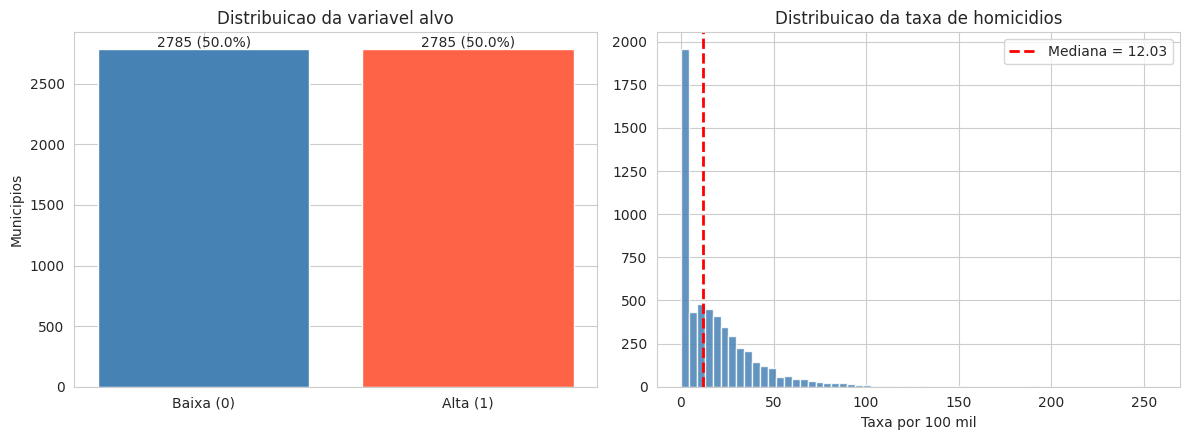

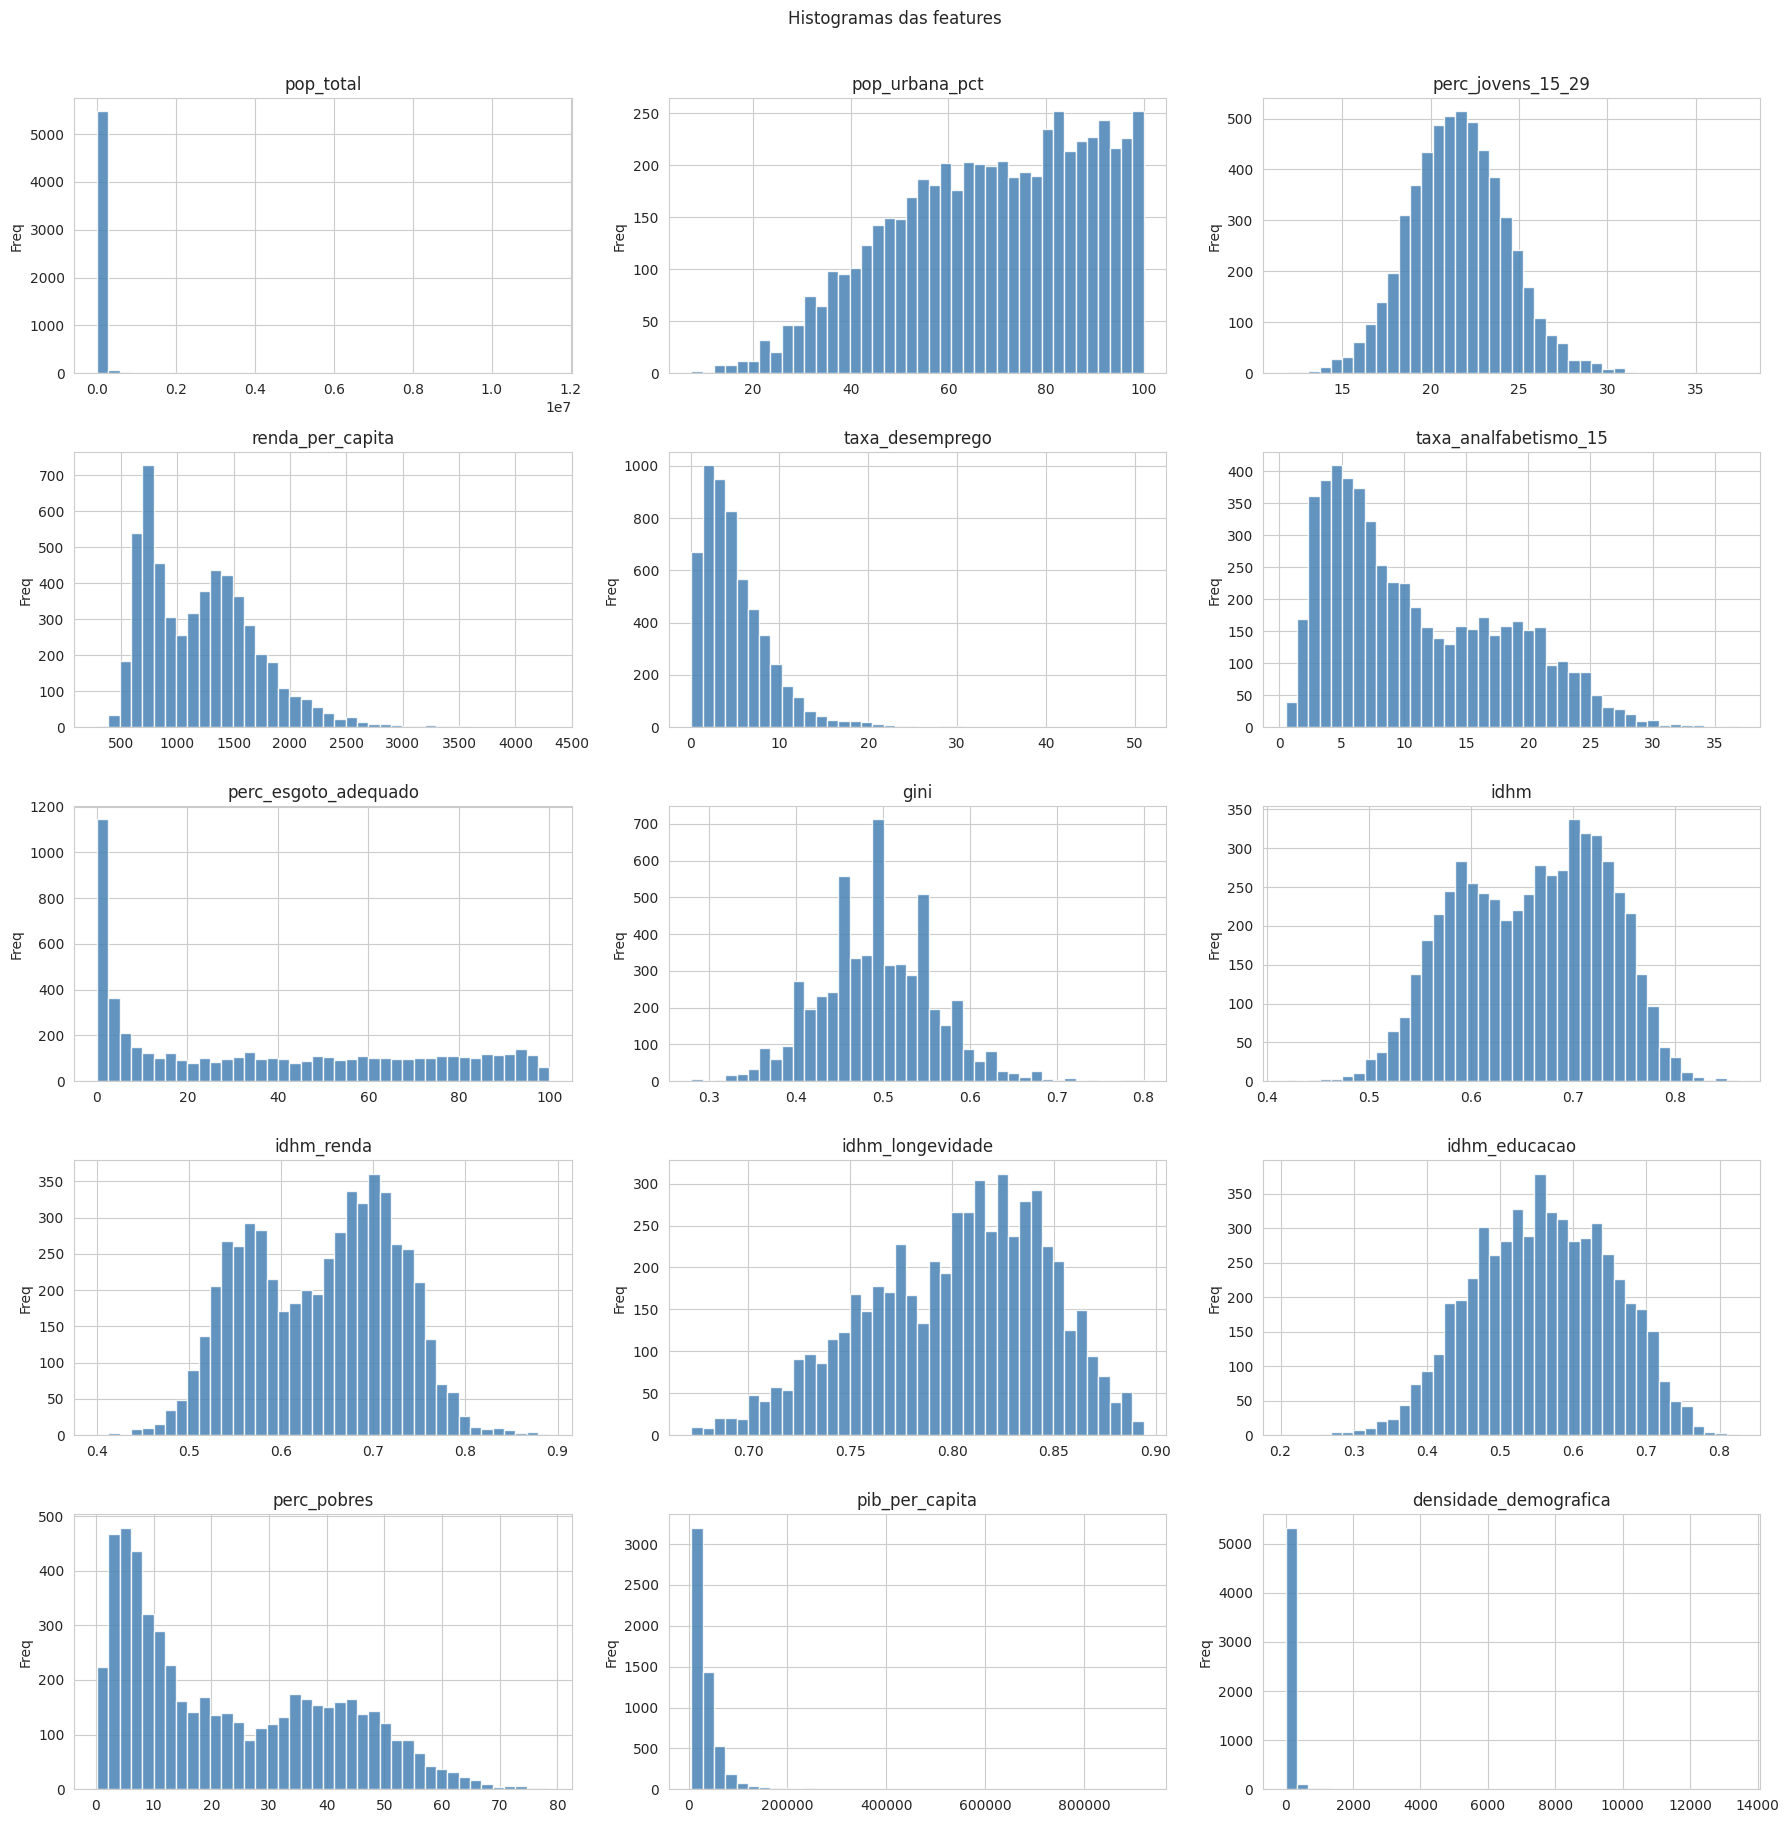

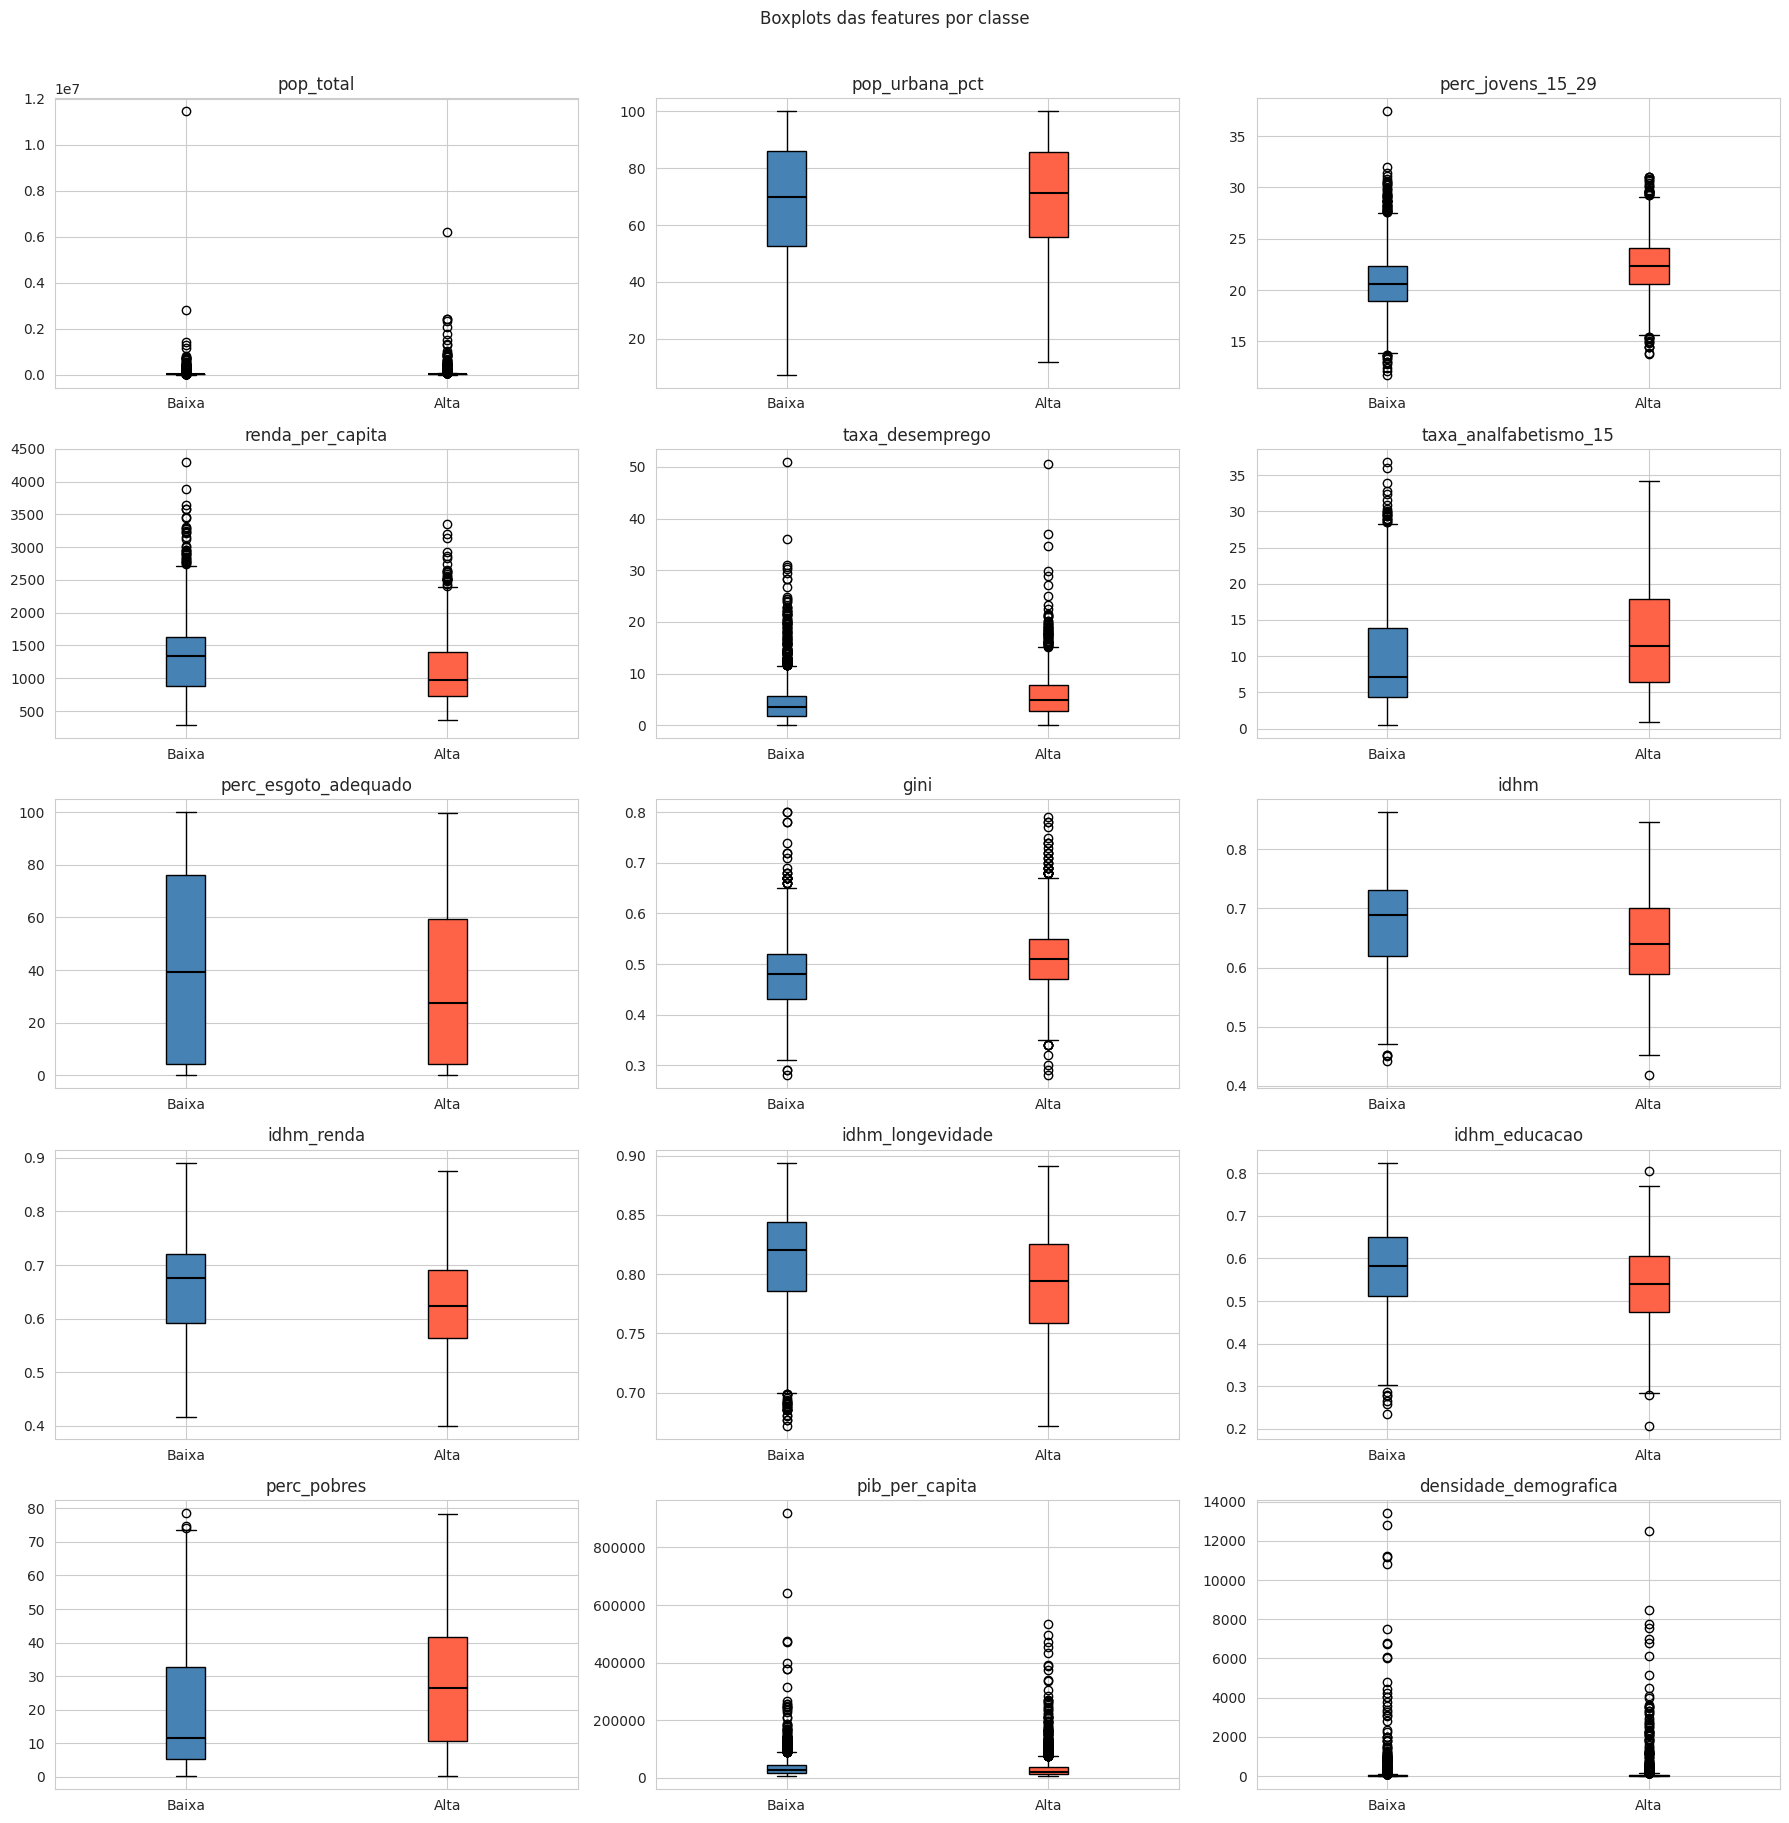

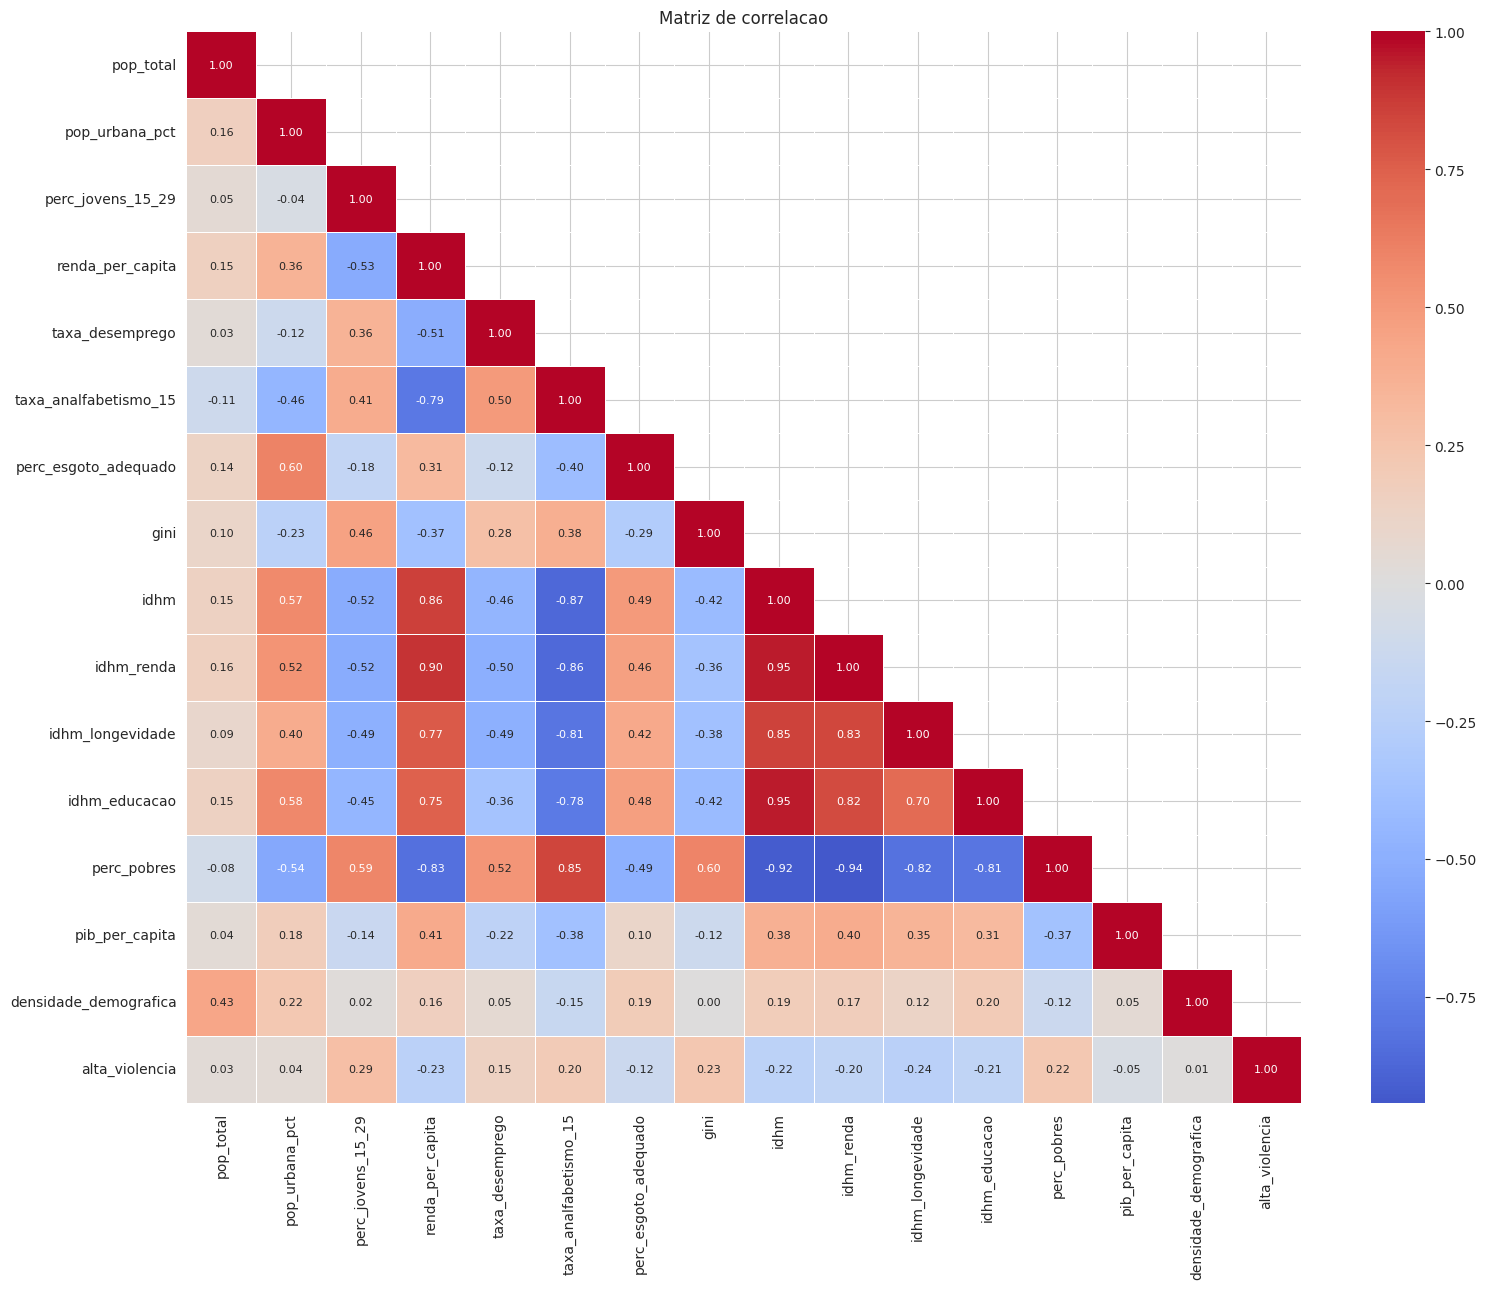

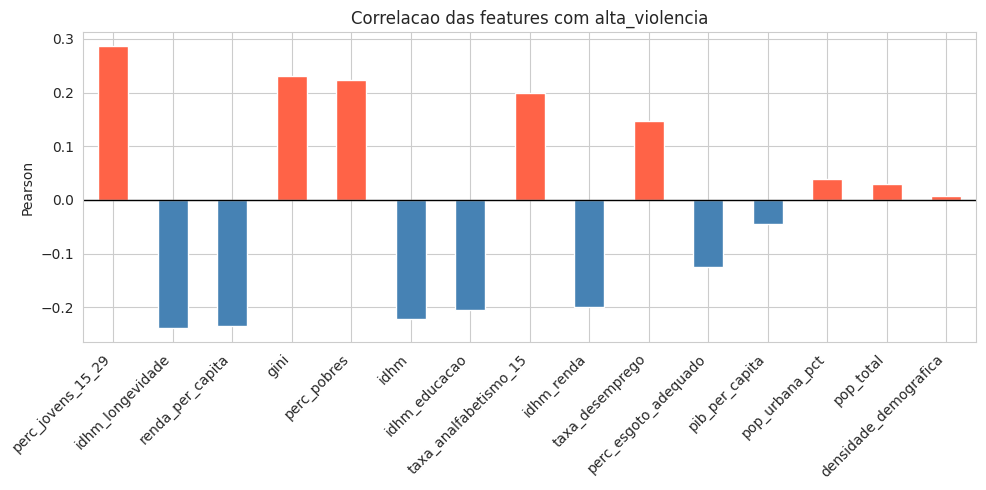

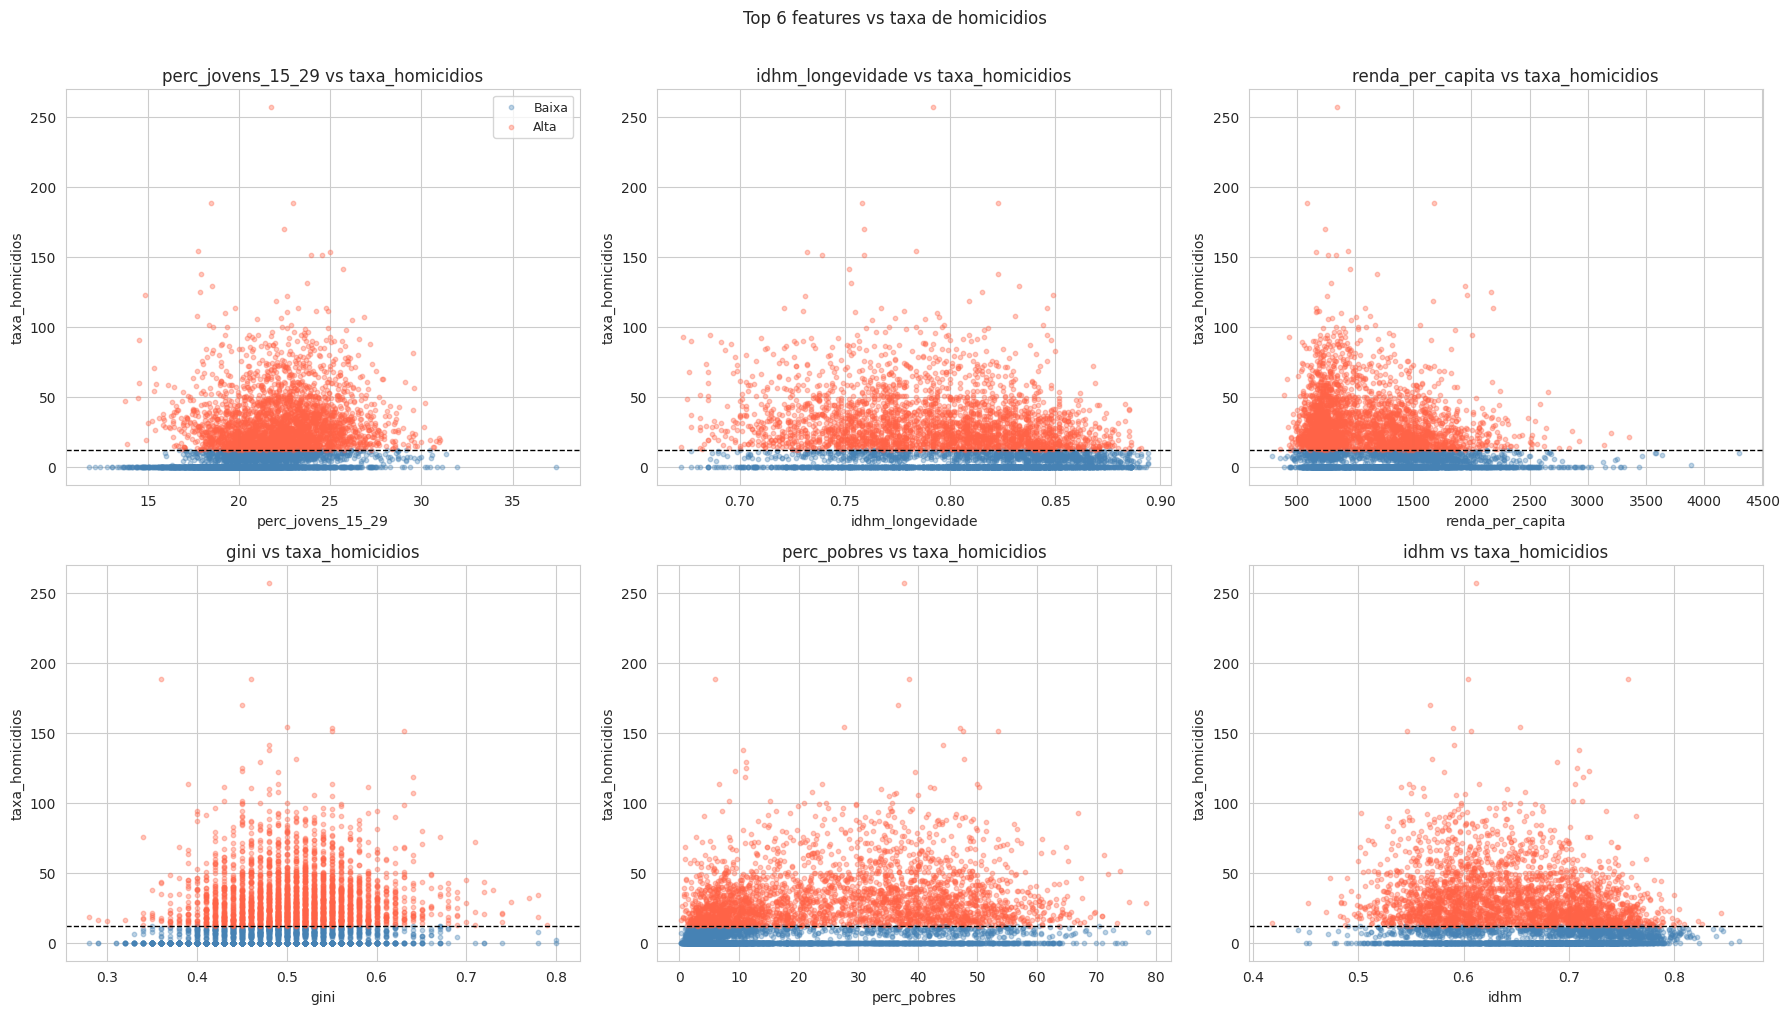

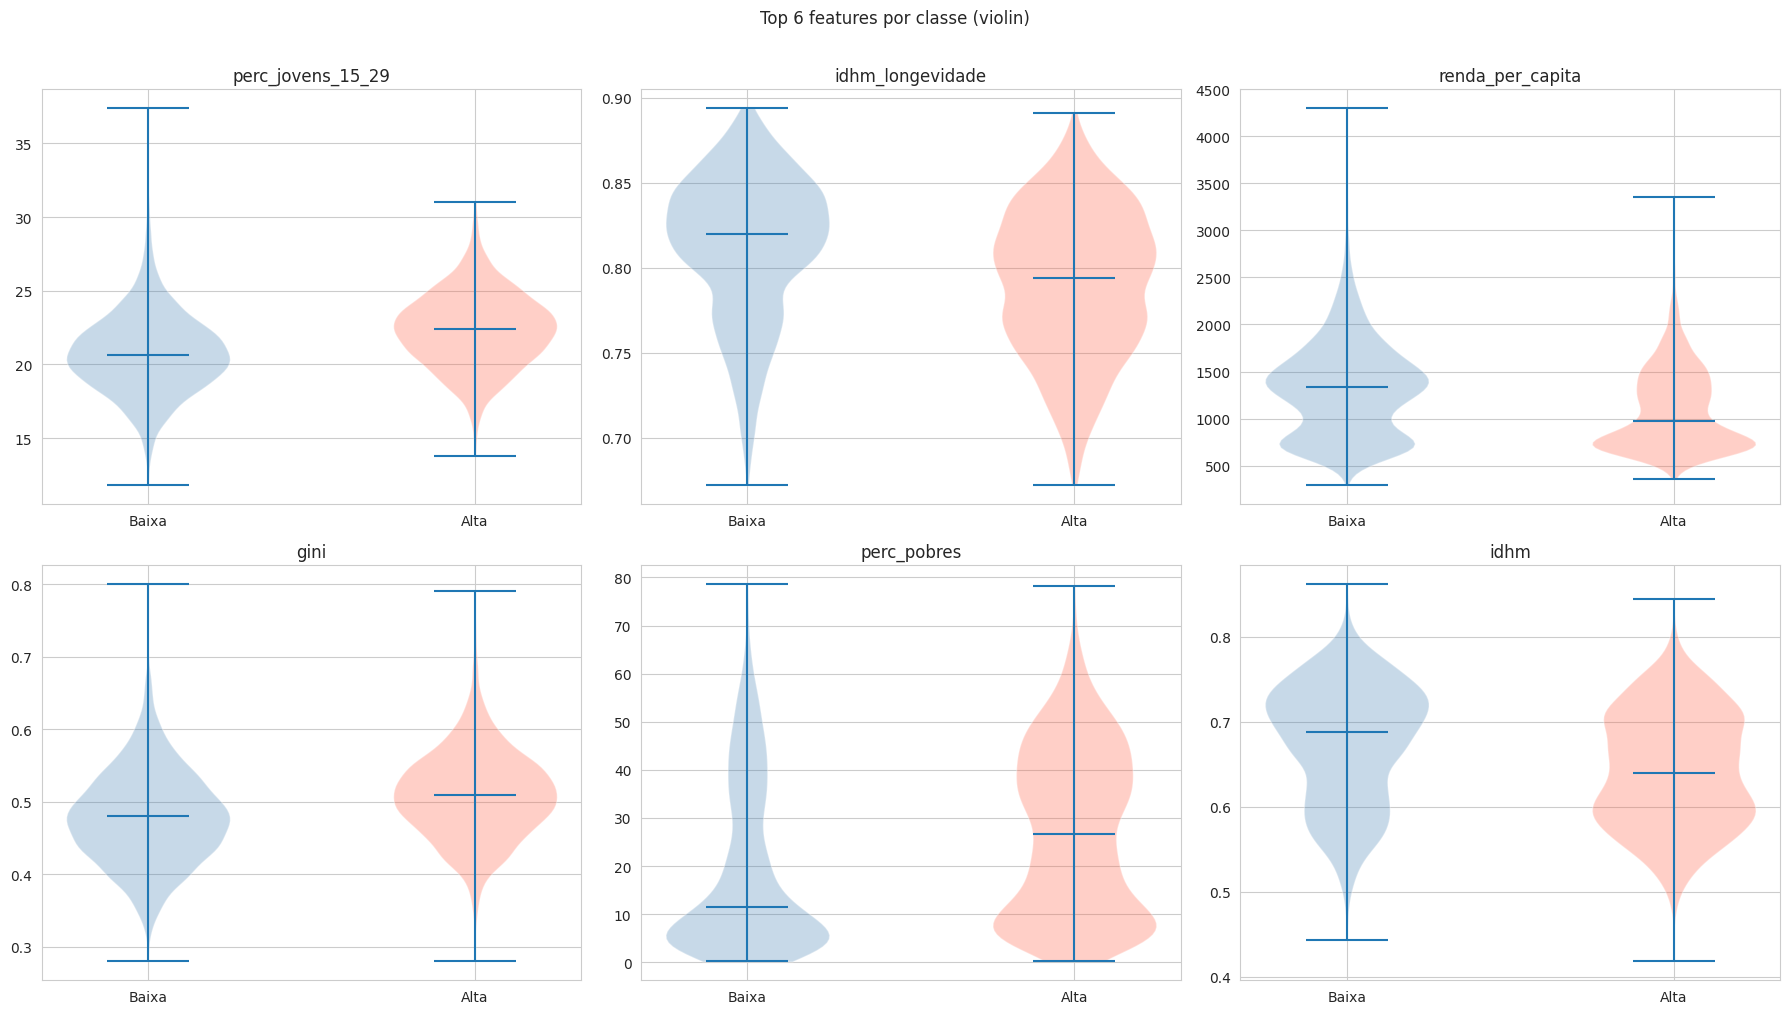

In [6]:
print("municipios:", len(dataset))
counts = dataset["alta_violencia"].value_counts().sort_index()
print("classes:", counts.to_dict())

corr_target = (
    dataset[FEATURES + ["alta_violencia"]]
    .corr(numeric_only=True)["alta_violencia"]
    .drop("alta_violencia")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
print("top correlacoes:")
print(corr_target.head(8).round(4).to_string())

mediana = dataset["taxa_homicidios"].median()
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].bar(["Baixa (0)", "Alta (1)"], counts.values, color=["steelblue", "tomato"])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 20, f"{v} ({v/len(dataset)*100:.1f}%)", ha="center", fontsize=10)
ax[0].set_title("Distribuicao da variavel alvo")
ax[0].set_ylabel("Municipios")

ax[1].hist(dataset["taxa_homicidios"], bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax[1].axvline(mediana, color="red", linestyle="--", linewidth=2, label=f"Mediana = {mediana:.2f}")
ax[1].set_title("Distribuicao da taxa de homicidios")
ax[1].set_xlabel("Taxa por 100 mil")
ax[1].legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_distribuicao_alvo_taxa.png", dpi=130)
plt.show()

n_cols = 3
n_rows = (len(FEATURES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.6))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    axes[i].hist(dataset[feat], bins=40, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(feat)
    axes[i].set_ylabel("Freq")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Histogramas das features", y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_histogramas_features.png", dpi=130)
plt.show()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.6))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    baixa = dataset.loc[dataset["alta_violencia"] == 0, feat]
    alta = dataset.loc[dataset["alta_violencia"] == 1, feat]
    bp = axes[i].boxplot(
        [baixa, alta],
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 1.5},
    )
    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][1].set_facecolor("tomato")
    axes[i].set_xticks([1, 2])
    axes[i].set_xticklabels(["Baixa", "Alta"])
    axes[i].set_title(feat)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Boxplots das features por classe", y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_boxplots_por_classe.png", dpi=130)
plt.show()

corr = dataset[FEATURES + ["alta_violencia"]].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Matriz de correlacao")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_matriz_correlacao.png", dpi=130)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["tomato" if v > 0 else "steelblue" for v in corr_target]
corr_target.plot(kind="bar", color=colors, ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Correlacao das features com alta_violencia")
ax.set_ylabel("Pearson")
ax.set_xticklabels(corr_target.index, rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_correlacao_com_alvo.png", dpi=130)
plt.show()

top_features = corr_target.abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    for classe, cor, label in [(0, "steelblue", "Baixa"), (1, "tomato", "Alta")]:
        subset = dataset[dataset["alta_violencia"] == classe]
        axes[i].scatter(subset[feat], subset["taxa_homicidios"], alpha=0.35, s=10, color=cor, label=label)
    axes[i].axhline(mediana, color="black", linestyle="--", linewidth=1)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("taxa_homicidios")
    axes[i].set_title(f"{feat} vs taxa_homicidios")
    if i == 0:
        axes[i].legend(fontsize=9)
plt.suptitle("Top 6 features vs taxa de homicidios", y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_scatter_top_features.png", dpi=130)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    data = [
        dataset.loc[dataset["alta_violencia"] == 0, feat].values,
        dataset.loc[dataset["alta_violencia"] == 1, feat].values,
    ]
    vp = axes[i].violinplot(data, positions=[0, 1], showmedians=True)
    vp["bodies"][0].set_facecolor("steelblue")
    vp["bodies"][1].set_facecolor("tomato")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Baixa", "Alta"])
    axes[i].set_title(feat)
plt.suptitle("Top 6 features por classe (violin)", y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_violin_top_features.png", dpi=130)
plt.show()


## 7) X, y, split e padronizacao

In [7]:
X = dataset[FEATURES].copy()
y = dataset["alta_violencia"].astype(int).copy()

N, p = X.shape
print("N:", N)
print("p:", p)

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)
X_test = scaler.transform(X_test_df)

print("treino:", X_train.shape, y_train.shape)
print("teste:", X_test.shape, y_test.shape)

N: 5570
p: 15
treino: (4456, 15) (4456,)
teste: (1114, 15) (1114,)


## 8) Salvamento dos artefatos

In [8]:
dataset.to_csv(PROCESSED_DIR / "dataset_municipios.csv", index=False)
np.save(PROCESSED_DIR / "X_train.npy", X_train)
np.save(PROCESSED_DIR / "X_test.npy", X_test)
np.save(PROCESSED_DIR / "y_train.npy", y_train.to_numpy())
np.save(PROCESSED_DIR / "y_test.npy", y_test.to_numpy())
(PROCESSED_DIR / "feature_names.txt").write_text("\n".join(FEATURES), encoding="utf-8")
joblib.dump(scaler, MODELS_DIR / "scaler.joblib")

print("arquivos salvos:")
print("- data/processed/dataset_municipios.csv")
print("- data/processed/X_train.npy")
print("- data/processed/X_test.npy")
print("- data/processed/y_train.npy")
print("- data/processed/y_test.npy")
print("- data/processed/feature_names.txt")
print("- models/scaler.joblib")

arquivos salvos:
- data/processed/dataset_municipios.csv
- data/processed/X_train.npy
- data/processed/X_test.npy
- data/processed/y_train.npy
- data/processed/y_test.npy
- data/processed/feature_names.txt
- models/scaler.joblib
